In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pygam import LinearGAM, s
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import statsmodels.formula.api as smf

C:\Users\aksha\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\aksha\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


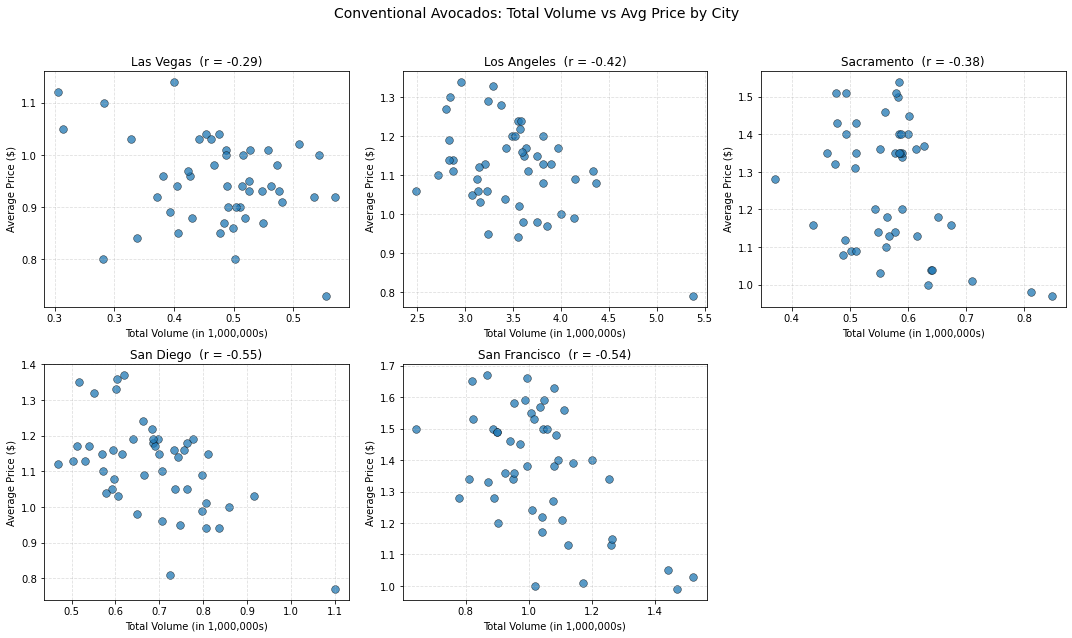

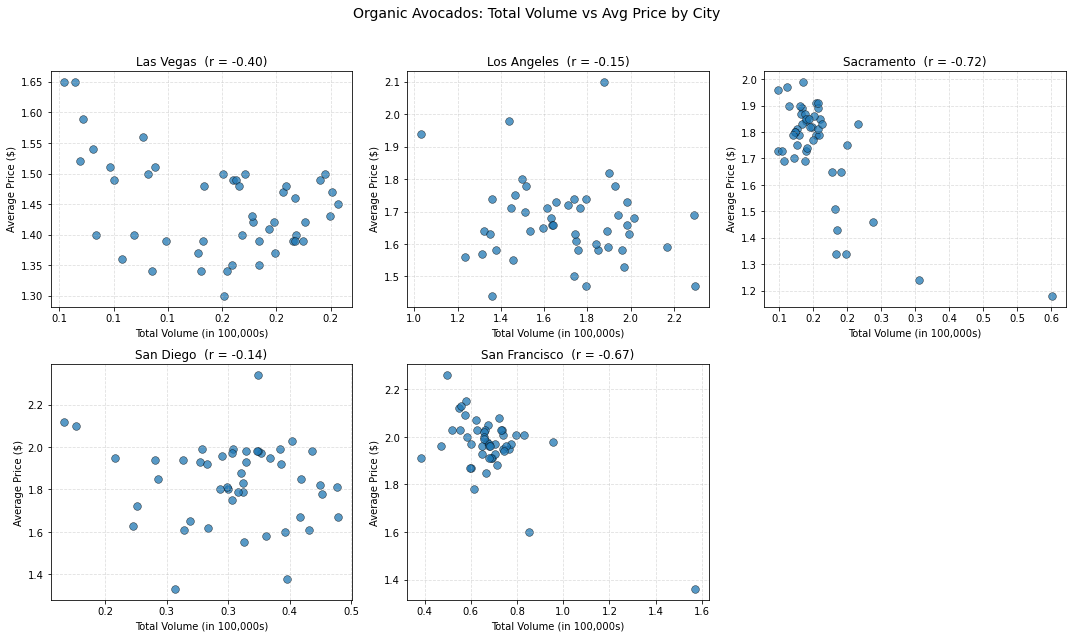

In [2]:
# ---- Load data ----
df = pd.read_csv("C:/Users/aksha/Documents/Github Datasets/Avocardo Price Elasticity/Dataset.csv")

cities = sorted(df["City"].unique())
n_cities = len(cities)
n_cols = 3
n_rows = math.ceil(n_cities / n_cols)


def plot_by_city(data, avocado_type, divisor, unit_label, filename):
    """Create a grid of scatter plots (Total Volume vs Avg Price), one per city.
    Each city's subplot uses its own x-axis scale, sized to that city's data,
    and reports the correlation between Price and Volume in the title."""
    subset = data[data["Type"] == avocado_type]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for i, city in enumerate(cities):
        ax = axes_flat[i]
        city_data = subset[subset["City"] == city]

        # X-axis range scaled to this city's own data
        x_min = city_data["Total Volume"].min()
        x_max = city_data["Total Volume"].max()
        x_pad = (x_max - x_min) * 0.05 if x_max > x_min else x_max * 0.05

        # Correlation between Price and Volume for this city
        corr = city_data["Avg Price"].corr(city_data["Total Volume"])

        ax.scatter(
            city_data["Total Volume"],
            city_data["Avg Price"],
            color="tab:blue",
            s=60,
            alpha=0.75,
            edgecolors="black",
            linewidths=0.5,
        )

        ax.set_title(f"{city}  (r = {corr:.2f})")
        ax.set_xlabel(f"Total Volume (in {unit_label})")
        ax.set_ylabel("Average Price ($)")
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f"{val / divisor:,.1f}"))
        ax.grid(True, linestyle="--", alpha=0.4)

    # Hide any unused subplot axes (if n_cities doesn't fill the grid exactly)
    for j in range(n_cities, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{avocado_type.capitalize()} Avocados: Total Volume vs Avg Price by City", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(filename, dpi=150)
    return fig


# ---- Plot 1: Conventional avocados, one subplot per city (units of 1,000,000) ----
plot_by_city(df, "conventional", divisor=1e6, unit_label="1,000,000s", filename="conventional_scatter.png")

# ---- Plot 2: Organic avocados, one subplot per city (units of 100,000) ----
plot_by_city(df, "organic", divisor=1e5, unit_label="100,000s", filename="organic_scatter.png")

plt.show()


=== Conventional Avocados: GAM Fit Evaluation ===
         City    R2  Pseudo_R2  EDoF  n
    Las Vegas 0.087      0.087 2.153 48
  Los Angeles 0.207      0.207 2.353 48
   Sacramento 0.210      0.210 2.877 48
    San Diego 0.311      0.311 2.114 48
San Francisco 0.319      0.319 2.386 48

=== Organic Avocados: GAM Fit Evaluation ===
         City    R2  Pseudo_R2  EDoF  n
    Las Vegas 0.412      0.412 3.902 48
  Los Angeles 0.025      0.025 2.124 48
   Sacramento 0.760      0.760 8.472 48
    San Diego 0.145      0.145 3.856 48
San Francisco 0.631      0.631 7.417 48


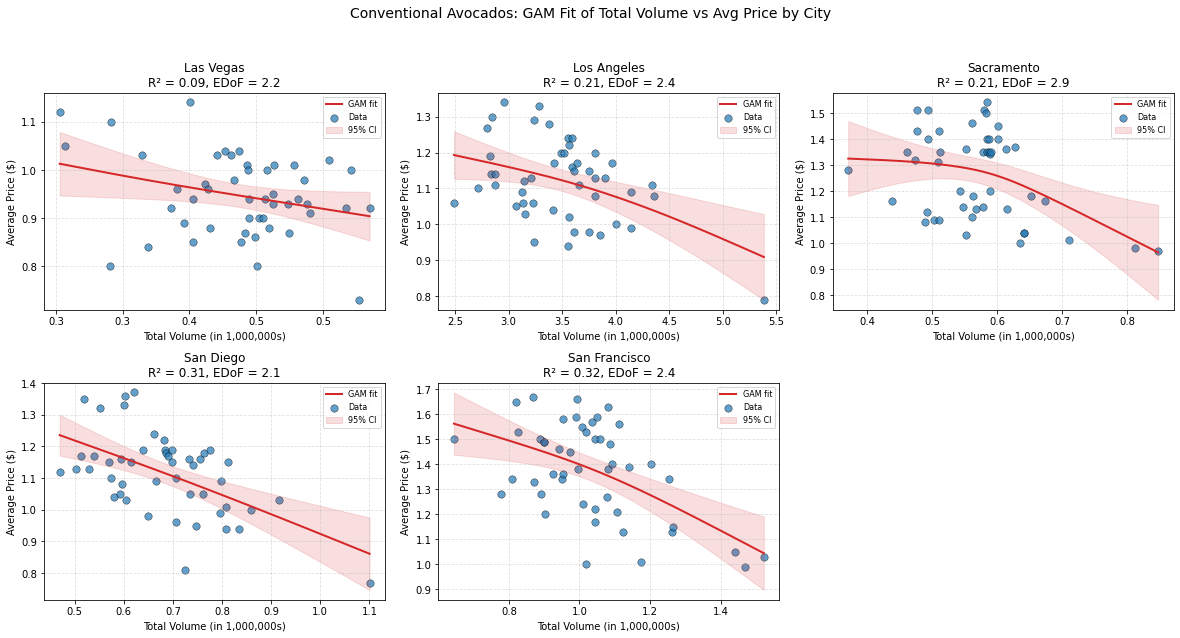

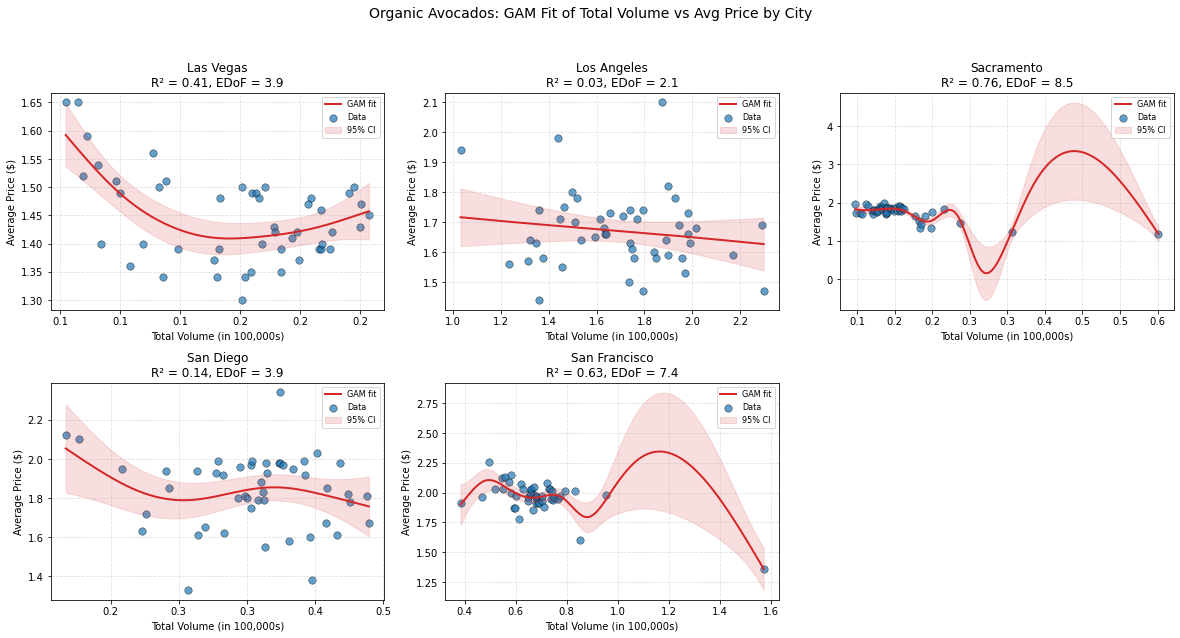

In [3]:
cities = sorted(df["City"].unique())
n_cities = len(cities)
n_cols = 3
n_rows = math.ceil(n_cities / n_cols)


def fit_gam(x, y):
    """Fit a LinearGAM with a single smooth spline term on x -> y."""
    X = x.values.reshape(-1, 1)
    # n_splines capped by sample size so small city samples don't overfit/error
    n_splines = int(np.clip(len(x) // 3, 4, 15))
    gam = LinearGAM(s(0, n_splines=n_splines)).gridsearch(X, y.values, progress=False)
    return gam


def evaluate_fit(gam, x, y):
    """Return R^2, pseudo R^2, and effective DoF for a fitted GAM."""
    X = x.values.reshape(-1, 1)
    y_pred = gam.predict(X)
    r2 = r2_score(y, y_pred)
    pseudo_r2 = gam.statistics_["pseudo_r2"]["explained_deviance"]
    edof = gam.statistics_["edof"]
    return r2, pseudo_r2, edof


def plot_gam_by_city(data, avocado_type, divisor, unit_label, filename):
    """Grid of per-city scatter plots with fitted GAM curve + evaluation."""
    subset = data[data["Type"] == avocado_type]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.5 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    results = []

    for i, city in enumerate(cities):
        ax = axes_flat[i]
        city_data = subset[subset["City"] == city].sort_values("Total Volume")
        x = city_data["Total Volume"]
        y = city_data["Avg Price"]

        # Scatter of raw data
        ax.scatter(x, y, color="tab:blue", s=55, alpha=0.7, edgecolors="black", linewidths=0.5, label="Data")

        # Fit GAM and predict over a smooth grid
        gam = fit_gam(x, y)
        x_grid = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
        y_pred = gam.predict(x_grid)
        conf_int = gam.confidence_intervals(x_grid, width=0.95)

        ax.plot(x_grid, y_pred, color="tab:red", linewidth=2, label="GAM fit")
        ax.fill_between(x_grid.flatten(), conf_int[:, 0], conf_int[:, 1],
                         color="tab:red", alpha=0.15, label="95% CI")

        r2, pseudo_r2, edof = evaluate_fit(gam, x, y)
        results.append({"City": city, "R2": r2, "Pseudo_R2": pseudo_r2, "EDoF": edof, "n": len(x)})

        ax.set_title(f"{city}\nR² = {r2:.2f}, EDoF = {edof:.1f}")
        ax.set_xlabel(f"Total Volume (in {unit_label})")
        ax.set_ylabel("Average Price ($)")
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f"{val / divisor:,.1f}"))
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize=8, loc="best")

    for j in range(n_cities, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{avocado_type.capitalize()} Avocados: GAM Fit of Total Volume vs Avg Price by City", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(filename, dpi=150)
    return pd.DataFrame(results)


# ---- Conventional avocados ----
conv_results = plot_gam_by_city(df, "conventional", divisor=1e6, unit_label="1,000,000s",
                                 filename="conventional_gam.png")

# ---- Organic avocados ----
org_results = plot_gam_by_city(df, "organic", divisor=1e5, unit_label="100,000s",
                                filename="organic_gam.png")

# ---- Print evaluation summary ----
print("\n=== Conventional Avocados: GAM Fit Evaluation ===")
print(conv_results.round(3).to_string(index=False))
print("\n=== Organic Avocados: GAM Fit Evaluation ===")
print(org_results.round(3).to_string(index=False))

plt.show()

In [4]:
"""
Predicted Volume by Price and City, from fitted GAMs
---------------------------------------------------------
For each city, fits the same GAM as before (Total Volume ~ f(Avg Price))
then uses it to predict Total Volume at a chosen set of price points.
Output is a table: rows = Price, columns = City, values = predicted Volume
(one such table per avocado type).
"""

cities = sorted(df["City"].unique())


def fit_gam(x, y):
    """Fit a LinearGAM with a single smooth spline term on x -> y."""
    X = x.values.reshape(-1, 1)
    n_splines = int(np.clip(len(x) // 3, 4, 15))
    gam = LinearGAM(s(0, n_splines=n_splines)).gridsearch(X, y.values, progress=False)
    return gam


def predict_volume_by_price(data, avocado_type, price_points):
    """Fit a GAM (Volume ~ f(Price)) per city, then predict Volume at each
    price point. Returns a DataFrame: rows = Price, columns = City."""
    subset = data[data["Type"] == avocado_type]

    predictions = {}
    for city in cities:
        city_data = subset[subset["City"] == city]
        x = city_data["Avg Price"]   # GAM input: Price
        y = city_data["Total Volume"]  # GAM target: Volume

        gam = fit_gam(x, y)

        price_grid = np.array(price_points).reshape(-1, 1)
        predicted_volume = gam.predict(price_grid)
        predictions[city] = predicted_volume

        # Flag prices outside this city's observed range (extrapolation risk)
        obs_min, obs_max = x.min(), x.max()
        out_of_range = [p for p in price_points if p < obs_min or p > obs_max]
        if out_of_range:
            print(f"Note: {city} ({avocado_type}) observed price range is "
                  f"[{obs_min:.2f}, {obs_max:.2f}] - prices {out_of_range} are "
                  f"extrapolated beyond the data and less reliable.")

    result = pd.DataFrame(predictions, index=price_points)
    result.index.name = "Price"

    # Build the same nested header shown in the screenshot: "Volume" over city names
    result.columns = pd.MultiIndex.from_product([["Volume"], result.columns])
    return result


# ---- Conventional avocados: predicted volume at these price points ----
conventional_prices = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
conventional_table = predict_volume_by_price(df, "conventional", conventional_prices)

print("\n=== Conventional Avocados: Predicted Volume by Price and City ===")
print(conventional_table.round(0).to_string())

# ---- Organic avocados: predicted volume at these price points ----
organic_prices = [1.3, 1.4, 1.5, 1.6, 1.7, 1.8]
organic_table = predict_volume_by_price(df, "organic", organic_prices)

print("\n=== Organic Avocados: Predicted Volume by Price and City ===")
print(organic_table.round(0).to_string())

# ---- Save to CSV ----
conventional_table.round(0).to_csv("predicted_volume_conventional.csv")
organic_table.round(0).to_csv("predicted_volume_organic.csv")
print("\nSaved: predicted_volume_conventional.csv, predicted_volume_organic.csv")

Note: Las Vegas (conventional) observed price range is [0.73, 1.14] - prices [1.2, 1.3] are extrapolated beyond the data and less reliable.
Note: Sacramento (conventional) observed price range is [0.97, 1.54] - prices [0.8, 0.9] are extrapolated beyond the data and less reliable.
Note: San Francisco (conventional) observed price range is [0.99, 1.67] - prices [0.8, 0.9] are extrapolated beyond the data and less reliable.

=== Conventional Avocados: Predicted Volume by Price and City ===
         Volume                                               
      Las Vegas Los Angeles Sacramento San Diego San Francisco
Price                                                         
0.8    400295.0   4889231.0  1511631.0  871465.0     1512797.0
0.9    457970.0   4110707.0  1107817.0  803648.0     1405161.0
1.0    458553.0   3605241.0   710252.0  740462.0     1297523.0
1.1    329575.0   3447539.0   534876.0  684770.0     1189826.0
1.2    463582.0   3406883.0   555934.0  638156.0     1090833.0
1.3 